In [27]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.metrics import confusion_matrix,roc_curve
import seaborn as sns
import  datetime
import pathlib
import cv2
import io
from google.colab import files
from PIL import Image
import tensorflow_datasets as tfds
import tensorflow_probability as tfp
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer,Dropout
from tensorflow.keras.layers import (GlobalAveragePooling2D,Activation,MaxPooling2D,Add,Conv2D,MaxPool2D,Dense,Flatten,InputLayer,BatchNormalization,Input,Embedding,Rescaling,Resizing,Reshape)
from tensorflow.keras.losses import BinaryCrossentropy,CategoricalCrossentropy,SparseCategoricalCrossentropy
from tensorflow.keras.metrics import Accuracy,CategoricalAccuracy,TopKCategoricalAccuracy,SparseCategoricalAccuracy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (Callback,CSVLogger,EarlyStopping,LearningRateScheduler,ModelCheckpoint,ReduceLROnPlateau)
from tensorflow.keras.regularizers import L2,L1
from tensorboard.plugins.hparams import api as hp
from google.colab import  drive


In [34]:
CONFIGURATION={
    "BATCH_SIZE":32,
    "IMSIZE":256,
    "LEARNING_RATE":1e-3,
    "N_EPOCHS": 20,
    "DROPOUT_RATE": 0.0,
    "REGULARIZATION_RATE": 0.0,
    "N_FILTERS": 6,
    "KERNEL_SIZE": 3,
    "N_STRIDES": 1,
    "POOL_SIZE": 2,
    "N_DENSE_1": 1024,
    "N_DENSE_2": 128,
    "NUM_CLASSES": 3,
    "PATCH_SIZE": 16,
    "PROJ_DIM": 768,
    "CLASS_NAMES": ["angry", "happy", "sad"],

}

In [3]:
train_directory = "/content/dataset/Emotions Dataset/Emotions Dataset/train"
val_directory = "/content/dataset/Emotions Dataset/Emotions Dataset/test"
CLASS_NAMES=["angry","happy","sad"]

In [4]:
!pip install -q kaggle

In [5]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [6]:
!chmod  600 /root/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d muhammadhananasghar/human-emotions-datasethes

Dataset URL: https://www.kaggle.com/datasets/muhammadhananasghar/human-emotions-datasethes
License(s): unknown
 89% 274M/309M [00:00<00:00, 823MB/s] 
100% 309M/309M [00:00<00:00, 853MB/s]


In [8]:
!unzip "/content/human-emotions-datasethes.zip" -d "/content/dataset/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/EmotionsDataset/data/nothing/720.jpg  
  inflating: /content/dataset/EmotionsDataset/data/nothing/721.jpg  
  inflating: /content/dataset/EmotionsDataset/data/nothing/722.jpg  
  inflating: /content/dataset/EmotionsDataset/data/nothing/723.jpg  
  inflating: /content/dataset/EmotionsDataset/data/nothing/724.jpg  
  inflating: /content/dataset/EmotionsDataset/data/nothing/725.jpg  
  inflating: /content/dataset/EmotionsDataset/data/nothing/726.jpg  
  inflating: /content/dataset/EmotionsDataset/data/nothing/727.jpg  
  inflating: /content/dataset/EmotionsDataset/data/nothing/728.jpg  
  inflating: /content/dataset/EmotionsDataset/data/nothing/729.jpg  
  inflating: /content/dataset/EmotionsDataset/data/nothing/73.jpg  
  inflating: /content/dataset/EmotionsDataset/data/nothing/730.jpg  
  inflating: /content/dataset/EmotionsDataset/data/nothing/731.jpg  
  inflating: /content/dataset/EmotionsDataset/data/no

# **DATASET LOADING**

In [9]:
train_dataset=tf.keras.utils.image_dataset_from_directory(
    train_directory,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    color_mode="rgb",
    batch_size=CONFIGURATION["BATCH_SIZE"],
    image_size=(CONFIGURATION["IMSIZE"],CONFIGURATION["IMSIZE"]),
    shuffle=True,
    seed=99,

)

Found 6799 files belonging to 3 classes.


In [10]:
val_dataset=tf.keras.utils.image_dataset_from_directory(
    val_directory,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    color_mode="rgb",
    batch_size=CONFIGURATION["BATCH_SIZE"],
    image_size=(CONFIGURATION["IMSIZE"],CONFIGURATION["IMSIZE"]),
    shuffle=True,
    seed=99,
)

Found 2278 files belonging to 3 classes.


In [11]:
for i in val_dataset.take(1):
  print(i)

(<tf.Tensor: shape=(32, 256, 256, 3), dtype=float32, numpy=
array([[[[ 20.        ,  20.        ,  20.        ],
         [ 19.1875    ,  19.1875    ,  19.1875    ],
         [ 19.        ,  19.        ,  19.        ],
         ...,
         [ 29.125     ,  29.125     ,  29.125     ],
         [ 25.        ,  25.        ,  25.        ],
         [ 25.        ,  25.        ,  25.        ]],

        [[ 20.        ,  20.        ,  20.        ],
         [ 19.847656  ,  19.847656  ,  19.847656  ],
         [ 19.8125    ,  19.8125    ,  19.8125    ],
         ...,
         [ 28.820312  ,  28.820312  ,  28.820312  ],
         [ 25.660156  ,  25.660156  ,  25.660156  ],
         [ 25.        ,  25.        ,  25.        ]],

        [[ 20.6875    ,  20.6875    ,  20.6875    ],
         [ 21.246094  ,  21.246094  ,  21.246094  ],
         [ 21.847656  ,  21.847656  ,  21.847656  ],
         ...,
         [ 25.3125    ,  25.3125    ,  25.3125    ],
         [ 22.375     ,  22.375     ,  22.375 

# **DATASET VISUALIZATION**

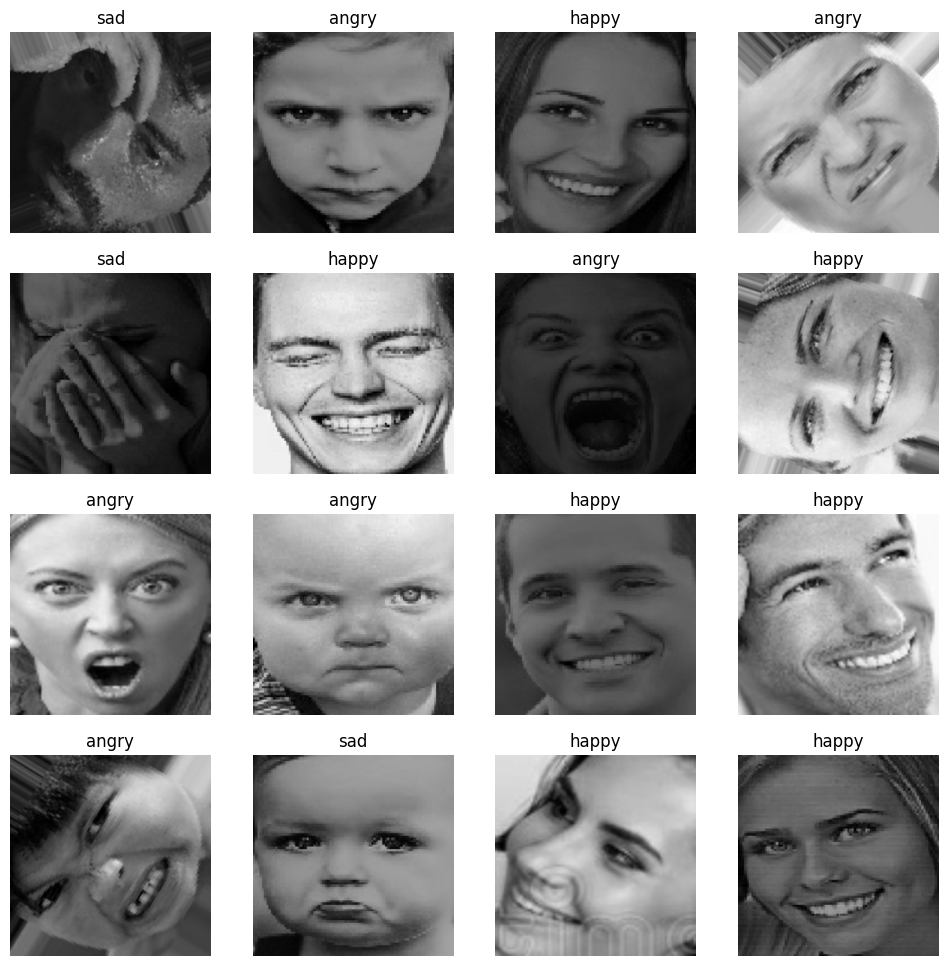

In [12]:
plt.figure(figsize=(12,12))
for images,label in train_dataset.take(1):
  for i in range(16):
    ax=plt.subplot(4,4,i+1)
    plt.imshow(images[i]/255)
    plt.title(CLASS_NAMES[tf.argmax(label[i],axis=0).numpy()])
    plt.axis("off")


# **DATASET PREPARATION**

In [13]:
training_dataset=(
    train_dataset
    .prefetch(tf.data.AUTOTUNE)
)


In [14]:
validation_dataset=(
    val_dataset
    .prefetch(tf.data.AUTOTUNE)
)

In [15]:
resize_rescale_layer=tf.keras.Sequential([
    Resizing(CONFIGURATION["IMSIZE"],CONFIGURATION["IMSIZE"]),
    Rescaling(1./255)
])

# **Model**

In [16]:
lenet_model=tf.keras.Sequential([
    InputLayer(input_shape=(None,None,3)),
    resize_rescale_layer,
    Conv2D(filters=CONFIGURATION["N_FILTERS"],kernel_size=CONFIGURATION["KERNEL_SIZE"],strides=CONFIGURATION["N_STRIDES"],padding="valid"
           ,activation="relu",kernel_regularizer=L2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(),
    MaxPool2D(pool_size=CONFIGURATION["POOL_SIZE"],strides=CONFIGURATION["N_STRIDES"]*2),
    Dropout(rate=CONFIGURATION["DROPOUT_RATE"]),
    Conv2D(filters=CONFIGURATION["N_FILTERS"]*2+4,kernel_size=CONFIGURATION["KERNEL_SIZE"],strides=CONFIGURATION["N_STRIDES"],padding="valid",
           activation="relu",kernel_regularizer=L2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(),
    MaxPool2D(pool_size=CONFIGURATION["POOL_SIZE"],strides=CONFIGURATION["N_STRIDES"]*2),

    Flatten(),
    Dense(CONFIGURATION["N_DENSE_1"],activation="relu",kernel_regularizer=L2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(),
    Dropout(rate=CONFIGURATION["DROPOUT_RATE"]),

    Dense(CONFIGURATION['N_DENSE_2'],activation="relu",kernel_regularizer=L2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(),

    Dense(CONFIGURATION["NUM_CLASSES"],activation="softmax")
    ])
lenet_model.summary()




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    62,981,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,118,451 (240.78 MB)

 Trainable params: 63,116,103 (240.77 MB)

 Non-trainable params: 2,348 (9.17 KB)

# **TRAINING**

In [17]:
loss_function=CategoricalCrossentropy(from_logits=False)
#loss_function=SparseCategoricalCrossentropy()

In [18]:
metrics=[CategoricalAccuracy(name="accuracy"),TopKCategoricalAccuracy(k=2,name="top_k_accuracy")]

In [19]:
y_true=[[0,1,0],[0,0,1]]
y_pred=[[0.05,0.95,0],[0.1,0.8,0.1]]
cce=tf.keras.losses.CategoricalCrossentropy()
print(cce(y_true,y_pred).numpy())


1.1769392


In [20]:
lenet_model.compile(
    optimizer=Adam(learning_rate=CONFIGURATION["LEARNING_RATE"]),
    loss=loss_function,
    metrics=metrics
)

In [21]:
history=lenet_model.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=CONFIGURATION["N_EPOCHS"],
    verbose=1
)

Epoch 1/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 28s 86ms/step - accuracy: 0.5078 - loss: 1.1844 - top_k_accuracy: 0.7950 - val_accuracy: 0.3323 - val_loss: 1.2238 - val_top_k_accuracy: 0.7739
Epoch 2/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.7244 - loss: 0.6619 - top_k_accuracy: 0.9099 - val_accuracy: 0.5435 - val_loss: 1.0431 - val_top_k_accuracy: 0.8174
Epoch 3/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.8418 - loss: 0.4034 - top_k_accuracy: 0.9610 - val_accuracy: 0.6225 - val_loss: 1.0316 - val_top_k_accuracy: 0.8771
Epoch 4/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9093 - loss: 0.2645 - top_k_accuracy: 0.9844 - val_accuracy: 0.7248 - val_loss: 0.9517 - val_top_k_accuracy: 0.8938
Epoch 5/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.9183 - loss: 0.2459 - top_k_accuracy: 0.9865 - val_accuracy: 0.7107 - val_loss: 1.0379 - val_top_k_accuracy: 0.8876
Epoch 6/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9385 - loss:

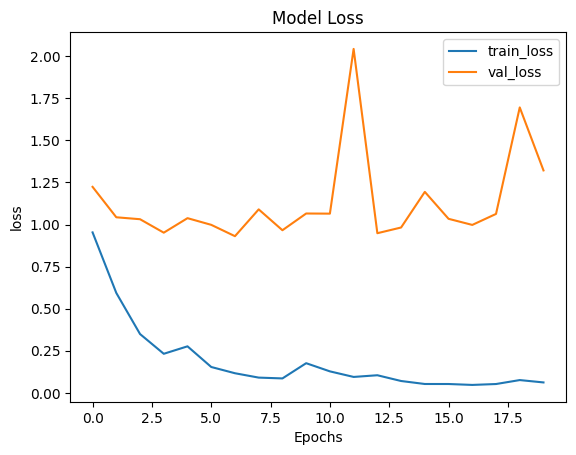

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.ylabel("loss")
plt.xlabel("Epochs")
plt.legend(["train_loss","val_loss"])
plt.show()

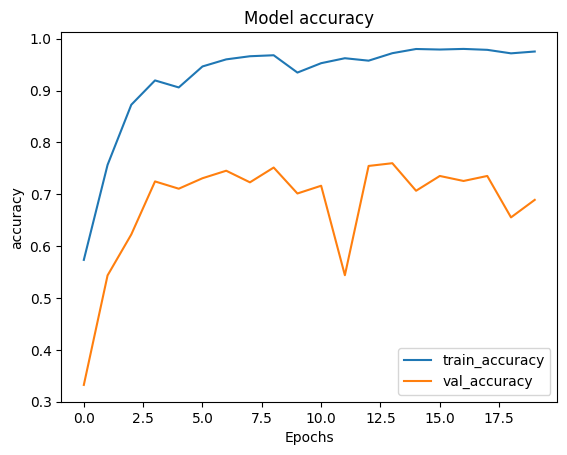

In [23]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model accuracy")
plt.ylabel("accuracy")
plt.xlabel("Epochs")
plt.legend(["train_accuracy","val_accuracy"])
plt.show()

# **EVALUATION**

In [24]:
lenet_model.evaluate(validation_dataset)

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.6750 - loss: 1.3626 - top_k_accuracy: 0.8780


[1.3215992450714111, 0.6892010569572449, 0.8849868178367615]

# ***TESTING***

In [38]:
 test_image=cv2.imread("/content/dataset/Emotions Dataset/Emotions Dataset/test/sad/10416.jpg_rotation_2.jpg")
 im=tf.constant(test_image,dtype=tf.float32)
 print(im.shape)
 im=tf.expand_dims(im,axis=0)
 print(CLASS_NAMES[tf.argmax(lenet_model(im),axis=-1).numpy()[0]])

(224, 224, 3)
sad


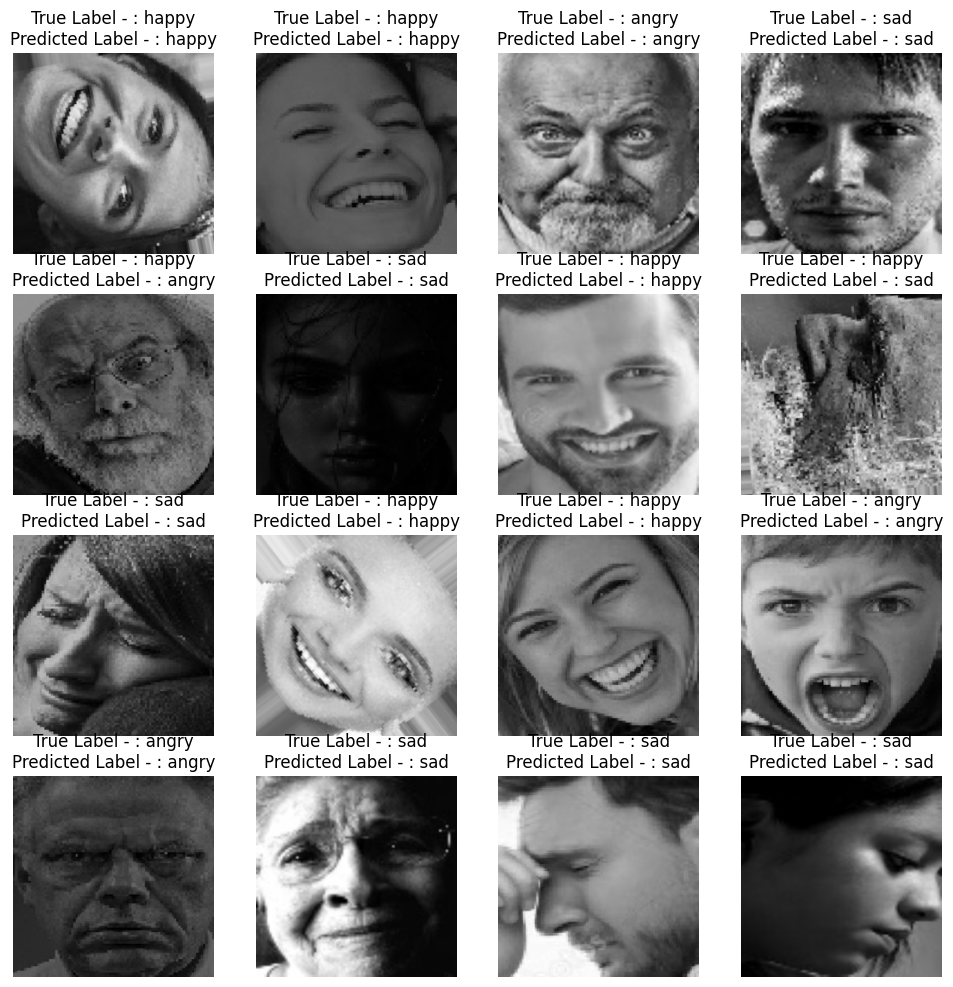

In [37]:
plt.figure(figsize = (12,12))

for images, labels in validation_dataset.take(1):
  for i in range(16):
    ax = plt.subplot(4,4, i+1)
    plt.imshow(images[i]/255.)

    plt.title("True Label - : " + CONFIGURATION["CLASS_NAMES"][tf.argmax(labels[i], axis = -1).numpy()]
              + "\n" + "Predicted Label - : "
              + CONFIGURATION["CLASS_NAMES"][int(tf.argmax(lenet_model(tf.expand_dims(images[i], axis = 0)), axis =-1).numpy()[0])] )
    plt.axis("off")

# **CONFUSION MATRIX**

In [39]:
labels=[]
predicted=[]
for im,label in validation_dataset:
  predicted.append(lenet_model(im))
  labels.append(label)
pred = np.concatenate([np.argmax(predicted[:-1], axis = -1).flatten(), np.argmax(predicted[-1], axis = -1).flatten()])
lab = np.concatenate([np.argmax(labels[:-1], axis = -1).flatten(), np.argmax(labels[-1], axis = -1).flatten()])

[[303  91 121]
 [ 39 845 122]
 [ 52 125 580]]


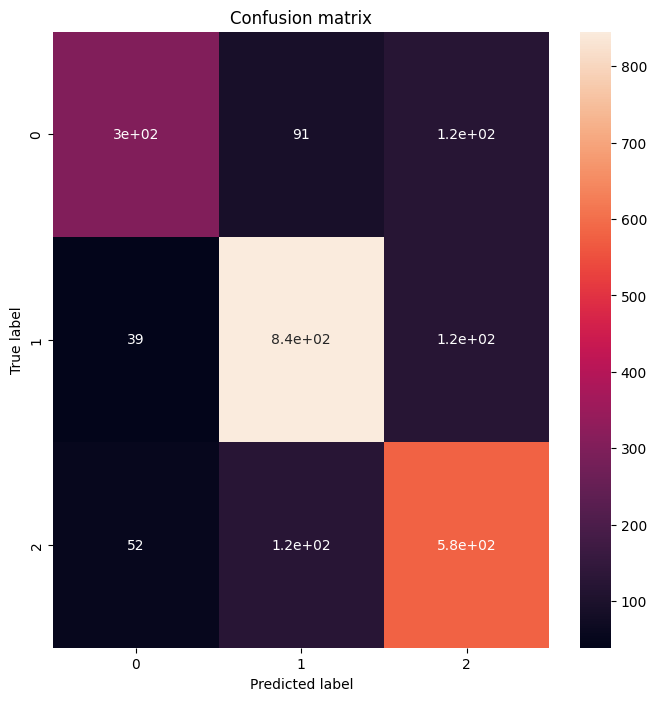

In [42]:
cm=confusion_matrix(lab,pred)
print(cm)
plt.figure(figsize=(8,8))

sns.heatmap(cm,annot=True)
plt.title("Confusion matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()